## 1. Import thư viện


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, ttest_ind, kruskal, pearsonr, spearmanr
from scipy.cluster.hierarchy import dendrogram, linkage
from itertools import combinations
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Đọc & chuẩn bị dữ liệu


In [18]:
df = pd.read_csv('water_withdrawal_clean.csv')
df['period'] = df['period'].str.strip()
df['attribute'] = df['attribute'].str.strip()

MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

df_vol  = df[df['unit'] == 'm3'].copy()
df_spec = df[df['unit'] == 'm3/ton'].copy()

for d in [df_vol, df_spec]:
    d['period'] = pd.Categorical(d['period'], categories=MONTHS, ordered=True)

# Pivot thể tích m3
pivot_vol = df_vol.pivot_table(index='period', columns='attribute', values='value').reindex(MONTHS)

# Chỉ giữ các chỉ số nguồn gốc (loại bỏ tổng DV+YB để không bị double count)
SOURCE_ATTRS = [
    'Surface water (Lake) (DV)',
    'Surface water (Lake) (YB)',
    'Ground water (wells) (DV)',
    'Tap wate (DV)',
    'Total Water Withdrawal (DV)',
    'Total Water Withdrawal (YB)',
    'Total Water Withdrawal (DV+YB)',
    'Specific Water Withdrawal (DV)',
    'Specific Water Withdrawal (YB)',
]

print(f' {len(df)} dòng | {df["attribute"].nunique()} chỉ số | 2 đơn vị | 12 tháng')
print(f'   Missing values (value): {df["value"].isna().sum()}')
df.head(8)

 132 dòng | 11 chỉ số | 2 đơn vị | 12 tháng
   Missing values (value): 15


,attribute,unit,period,value
0,Surface water (Lake) (DV),m3,Jan,4987.0
1,Surface water (Lake) (YB),m3,Jan,0.0
2,Surface water (Lake) (DV+YB),m3,Jan,4987.0
3,Ground water (wells) (DV),m3,Jan,0.0
4,Tap wate (DV),m3,Jan,658.0
5,Total Water Withdrawal (DV),m3,Jan,5645.0
6,Total Water Withdrawal (YB),m3,Jan,0.0
7,Total Water Withdrawal (DV+YB),m3,Jan,5645.0


## 3. Tổng quan & Thống kê mô tả


In [19]:
print('Missing values per column:')
print(df.isnull().sum())
print()
missing_rows = df[df['value'].isna()]
print(f'Các dòng bị thiếu ({len(missing_rows)} dòng):')
display(missing_rows)
print()
# Phân tích ý nghĩa của missing values
if len(missing_rows) > 0:
    missing_summary = missing_rows.groupby('attribute').agg(
        missing_count=('value', 'count'),
        tháng_thiếu=('period', lambda x: list(x))
    ).reset_index()
    print('Phân tích Missing Values theo chỉ số:')
    display(missing_summary)
    print()
print('Lưu ý diễn giải:')
print('  - NaN ≠ 0: Giá trị thiếu có thể do nhà máy không hoạt động, chưa ghi nhận, hoặc không phát sinh dữ liệu')
print('  - Các chỉ số liên quan đến YB có missing → kết quả tương quan DV-YB cần đọc thận trọng')
print('  - Cần xác nhận với đơn vị vận hành: thiếu do không hoạt động hay do lỗi ghi chép?')
print()
print('Thống kê (m³) — chỉ tính các giá trị có sẵn (bỏ NaN):')
display(df_vol.groupby('attribute')['value'].agg(
    Count='count', Mean='mean', Std='std', Min='min', Median='median', Max='max'
).round(2))


Missing values per column:
attribute     0
unit          0
period        0
value        15
dtype: int64

Các dòng bị thiếu (15 dòng):


,attribute,unit,period,value
9,Specific Water Withdrawal (YB),m3/ton,Jan,NaN
20,Specific Water Withdrawal (YB),m3/ton,Feb,NaN
31,Specific Water Withdrawal (YB),m3/ton,Mar,NaN
42,Specific Water Withdrawal (YB),m3/ton,Apr,NaN
53,Specific Water Withdrawal (YB),m3/ton,May,NaN
64,Specific Water Withdrawal (YB),m3/ton,Jun,NaN
75,Specific Water Withdrawal (YB),m3/ton,Jul,NaN
86,Specific Water Withdrawal (YB),m3/ton,Aug,NaN
91,Ground water (wells) (DV),m3,Sep,NaN
97,Specific Water Withdrawal (YB),m3/ton,Sep,NaN



Phân tích Missing Values theo chỉ số:


,attribute,missing_count,tháng_thiếu
0,Ground water (wells) (DV),0,"[Sep, Oct, Nov, Dec]"
1,Specific Water Withdrawal (YB),0,"[Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, ..."



Lưu ý diễn giải:
  - NaN ≠ 0: Giá trị thiếu có thể do nhà máy không hoạt động, chưa ghi nhận, hoặc không phát sinh dữ liệu
  - Các chỉ số liên quan đến YB có missing → kết quả tương quan DV-YB cần đọc thận trọng
  - Cần xác nhận với đơn vị vận hành: thiếu do không hoạt động hay do lỗi ghi chép?

Thống kê (m³) — chỉ tính các giá trị có sẵn (bỏ NaN):


,Count,Mean,Std,Min,Median,Max
attribute,,,,,,
Ground water (wells) (DV),8,0.00,0.00,0.0,0.0,0.0
Surface water (Lake) (DV),12,6090.67,1198.50,3058.0,6323.0,7894.0
Surface water (Lake) (DV+YB),12,6090.67,1198.50,3058.0,6323.0,7894.0
Surface water (Lake) (YB),12,0.00,0.00,0.0,0.0,0.0
Tap wate (DV),12,1291.58,416.18,631.0,1290.5,2083.0
Total Water Withdrawal (DV),12,7382.25,1354.01,4256.0,7719.0,9017.0
Total Water Withdrawal (DV+YB),12,7382.25,1354.01,4256.0,7719.0,9017.0
Total Water Withdrawal (YB),12,0.00,0.00,0.0,0.0,0.0


## 4. Xu hướng tổng quan & Heatmap


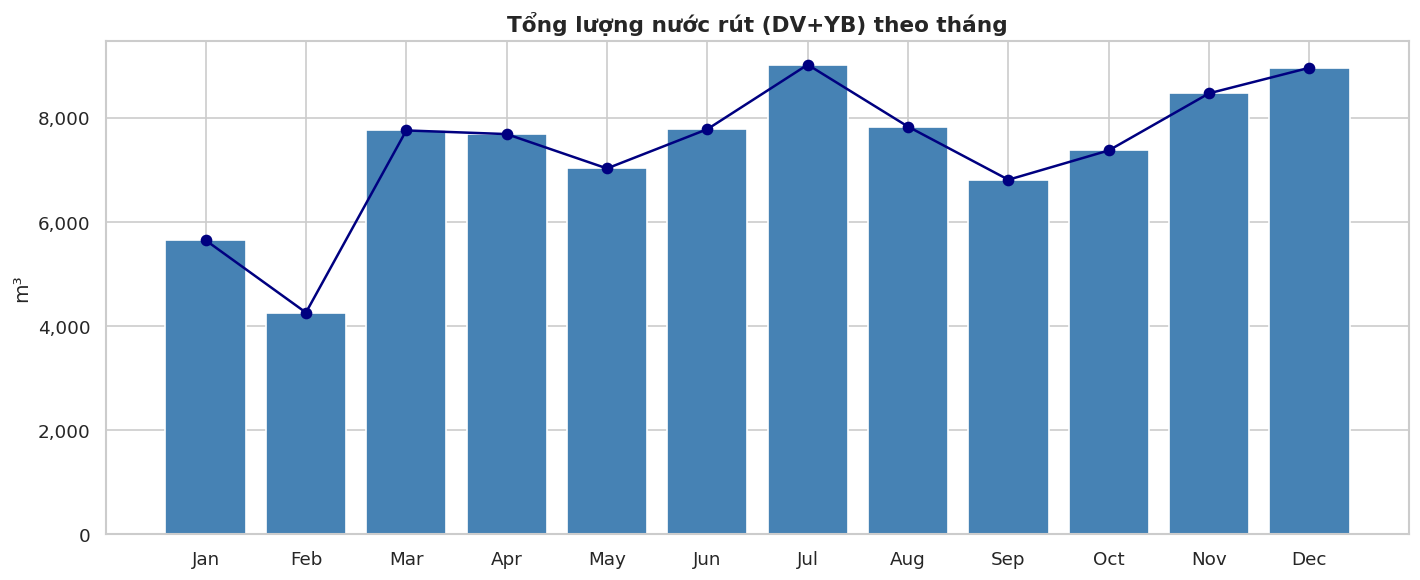

In [20]:
# Tổng lượng nước rút DV+YB
total = df_vol[df_vol['attribute'] == 'Total Water Withdrawal (DV+YB)'].sort_values('period')

fig, ax = plt.subplots()
ax.bar(total['period'].astype(str), total['value'], color='steelblue', edgecolor='white')
ax.plot(total['period'].astype(str), total['value'], marker='o', color='navy', linewidth=1.5)
ax.set_title('Tổng lượng nước rút (DV+YB) theo tháng', fontsize=13, fontweight='bold')
ax.set_ylabel('m³')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout(); plt.show()

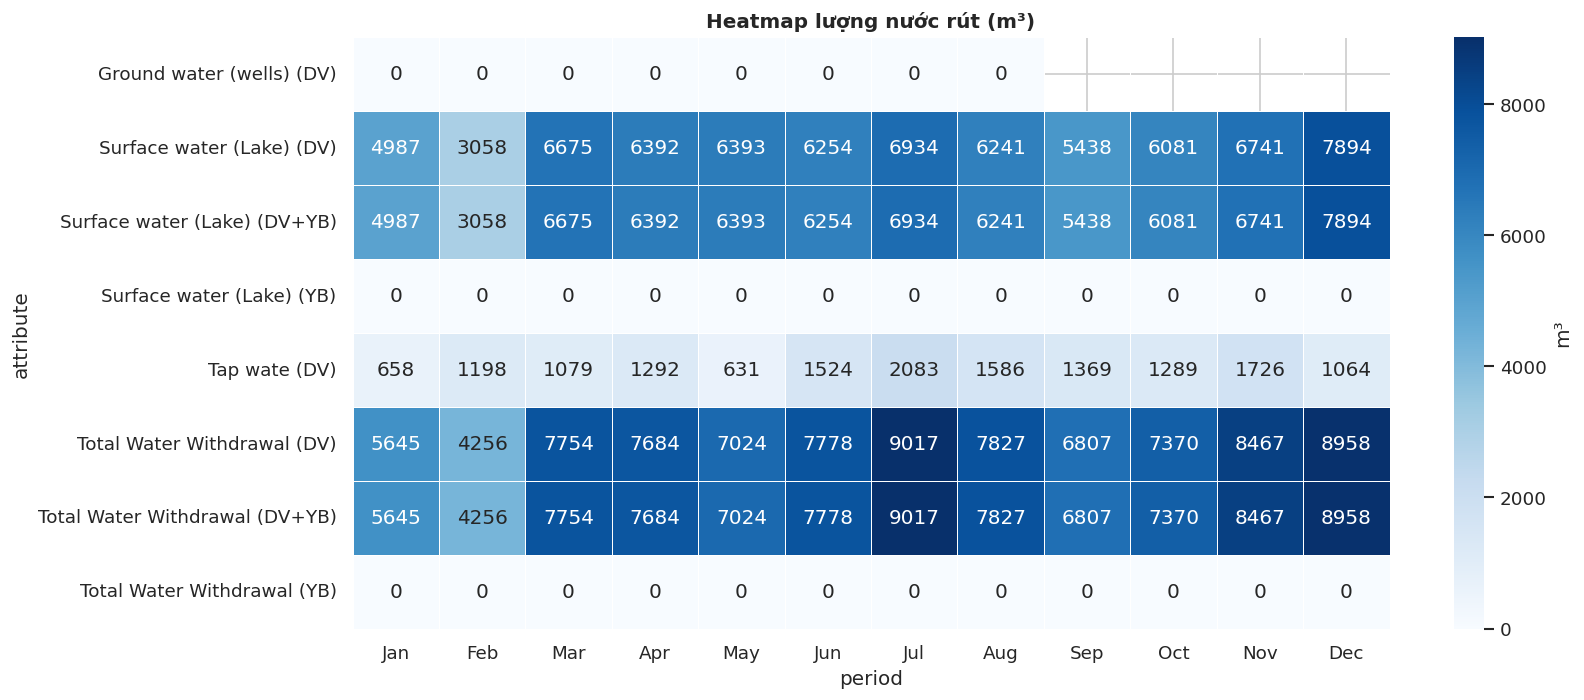

In [21]:
# Heatmap m3
pivot_heat = df_vol.pivot_table(
    index='attribute', columns='period', values='value', aggfunc='mean'
)[MONTHS]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_heat, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.4, ax=ax, mask=pivot_heat.isna(),
            cbar_kws={'label': 'm³'})
ax.set_title('Heatmap lượng nước rút (m³)', fontsize=12, fontweight='bold')
plt.yticks(rotation=0); plt.tight_layout(); plt.show()

## 5. Ma trận tương quan — Pearson & Spearman


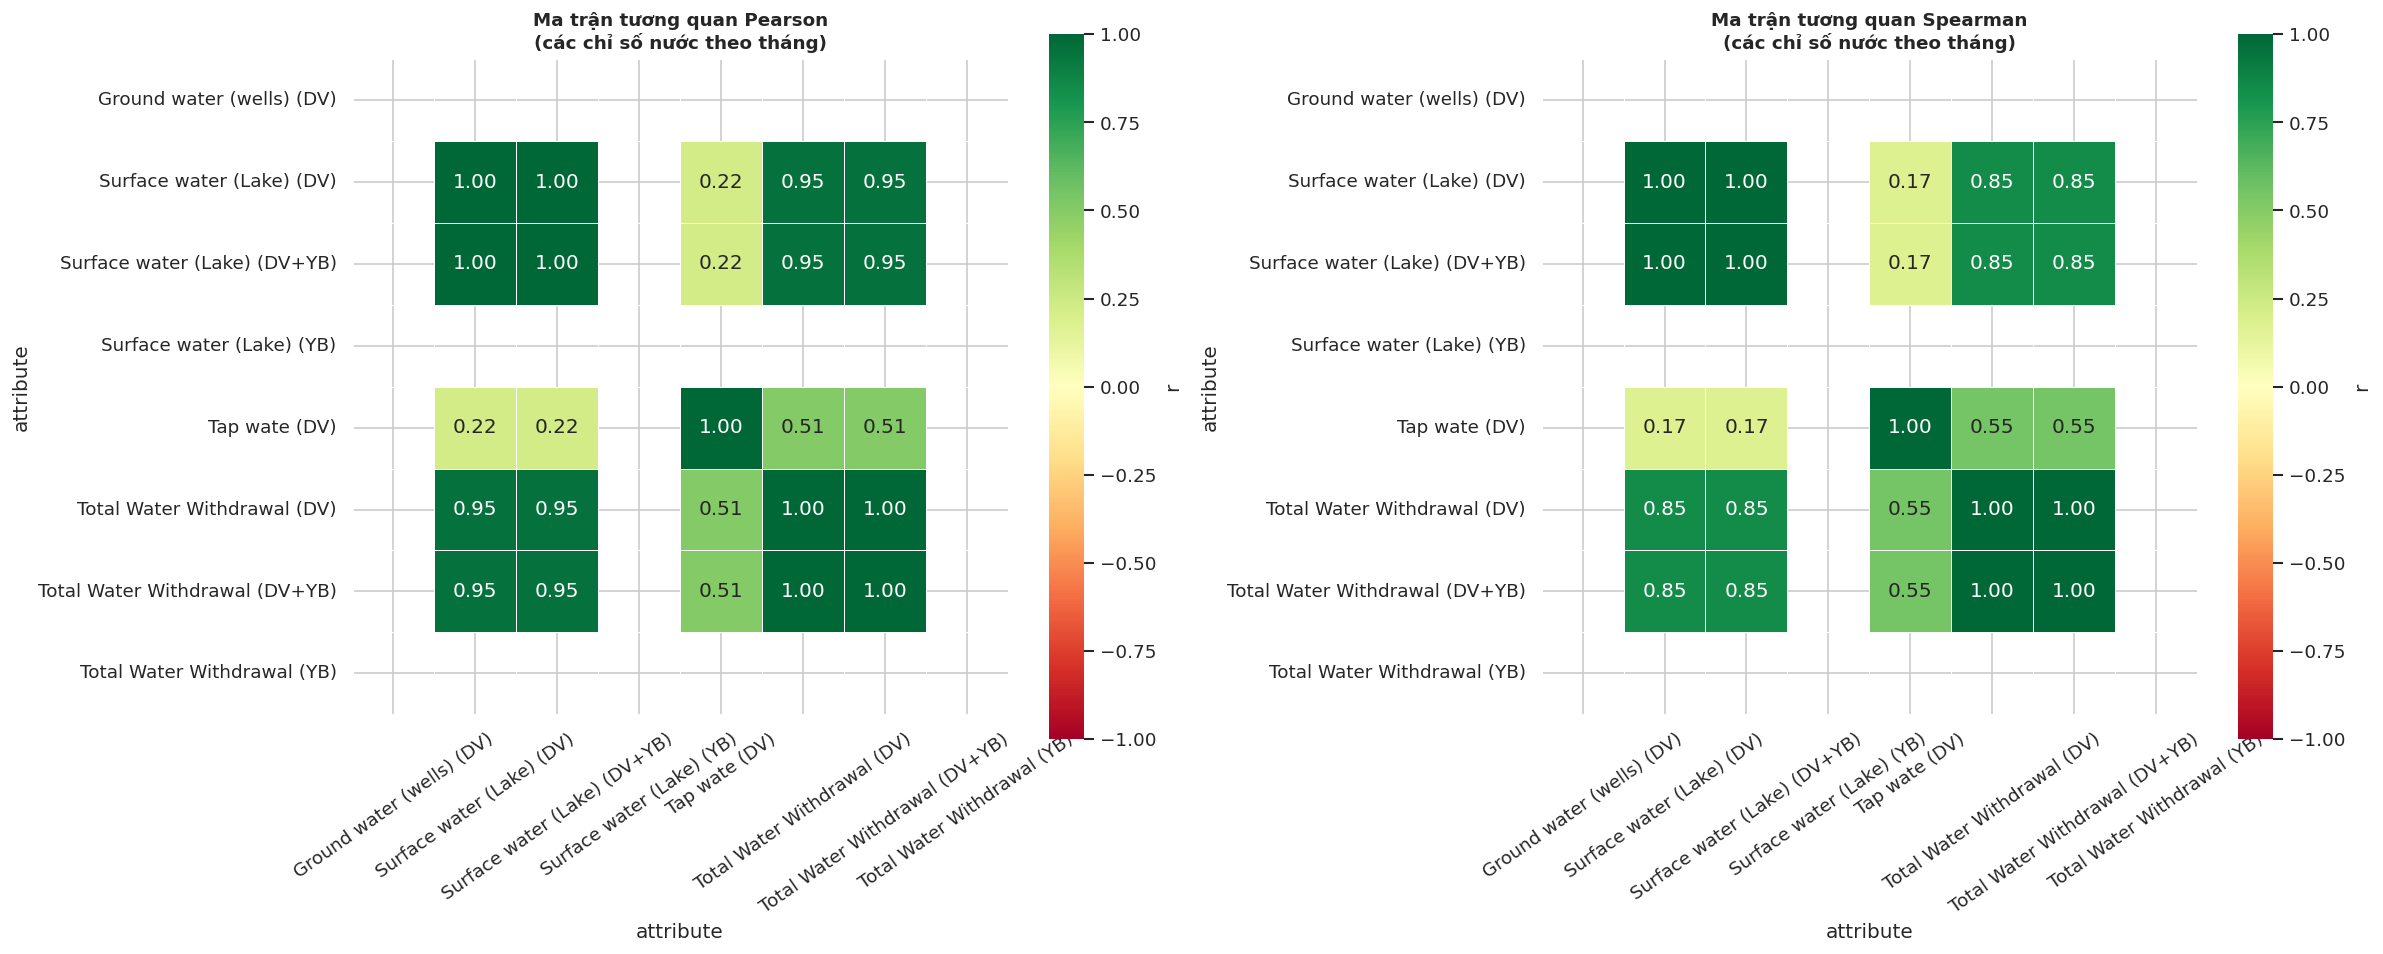

In [22]:
# Pivot dạng rộng: index=period, columns=attribute
pivot_wide = df_vol.pivot_table(index='period', columns='attribute', values='value')
pivot_wide = pivot_wide.reindex(MONTHS)  # reindex rows (period)

# Chỉ giữ cột có đủ dữ liệu
cols_enough = pivot_wide.columns[pivot_wide.notna().sum() >= 8]
pw = pivot_wide[cols_enough].fillna(0)  # pw: rows=months, cols=attributes

corr_p = pw.corr(method='pearson')
corr_s = pw.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, corr_m, title in zip(axes, [corr_p, corr_s], ['Pearson', 'Spearman']):
    sns.heatmap(corr_m, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1, linewidths=0.4, square=True,
                ax=ax, cbar_kws={'label': 'r'})
    ax.set_title(f'Ma trận tương quan {title}\n(các chỉ số nước theo tháng)',
                 fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=35)
    ax.tick_params(axis='y', rotation=0)
plt.tight_layout(); plt.show()

In [23]:
TOTAL_ATTRS = [c for c in cols_enough if 'Total Water Withdrawal' in c]
COMPONENT_ATTRS = [c for c in cols_enough if 'Total Water Withdrawal' not in c]

corr_pairs = []
for c1, c2 in combinations(cols_enough, 2):
    r_p = corr_p.loc[c1, c2]
    r_s = corr_s.loc[c1, c2]
    # Đánh dấu tương quan cơ học: biến tổng vs biến thành phần
    source_kws = ['Surface water', 'Ground water', 'Tap wate']
    is_mechanical = (
        (c1 in TOTAL_ATTRS and c2 in TOTAL_ATTRS) or
        (c1 in TOTAL_ATTRS and any(kw in c2 for kw in source_kws)) or
        (c2 in TOTAL_ATTRS and any(kw in c1 for kw in source_kws))
    )
    corr_pairs.append({'Chỉ số A': c1, 'Chỉ số B': c2,
                        'Pearson r': round(r_p,3), 'Spearman r': round(r_s,3),
                        'Ghi chú': '⚙️ Cơ học' if is_mechanical else ''})

df_cpairs = pd.DataFrame(corr_pairs).sort_values('Pearson r', key=abs, ascending=False)
df_meaningful = df_cpairs[df_cpairs['Ghi chú'] == '']

print('Tất cả cặp tương quan (có đánh dấu cơ học):')
display(df_cpairs.head(15))
print()
print('Cặp tương quan có ý nghĩa thực sự (loại trừ cơ học):')
display(df_meaningful.head(10))
strong_meaningful = df_meaningful[df_meaningful['Pearson r'].abs() > 0.7]
print(f'\n  Tương quan dương mạnh |r|>0.7 (không cơ học): {len(strong_meaningful)} cặp')

Tất cả cặp tương quan (có đánh dấu cơ học):


,Chỉ số A,Chỉ số B,Pearson r,Spearman r,Ghi chú
7,Surface water (Lake) (DV),Surface water (Lake) (DV+YB),1.000,1.000,
25,Total Water Withdrawal (DV),Total Water Withdrawal (DV+YB),1.000,1.000,⚙️ Cơ học
16,Surface water (Lake) (DV+YB),Total Water Withdrawal (DV+YB),0.954,0.846,⚙️ Cơ học
10,Surface water (Lake) (DV),Total Water Withdrawal (DV),0.954,0.846,⚙️ Cơ học
15,Surface water (Lake) (DV+YB),Total Water Withdrawal (DV),0.954,0.846,⚙️ Cơ học
11,Surface water (Lake) (DV),Total Water Withdrawal (DV+YB),0.954,0.846,⚙️ Cơ học
23,Tap wate (DV),Total Water Withdrawal (DV+YB),0.506,0.552,⚙️ Cơ học
22,Tap wate (DV),Total Water Withdrawal (DV),0.506,0.552,⚙️ Cơ học
9,Surface water (Lake) (DV),Tap wate (DV),0.224,0.175,
14,Surface water (Lake) (DV+YB),Tap wate (DV),0.224,0.175,



Cặp tương quan có ý nghĩa thực sự (loại trừ cơ học):


,Chỉ số A,Chỉ số B,Pearson r,Spearman r,Ghi chú
7,Surface water (Lake) (DV),Surface water (Lake) (DV+YB),1.000,1.000,
9,Surface water (Lake) (DV),Tap wate (DV),0.224,0.175,
14,Surface water (Lake) (DV+YB),Tap wate (DV),0.224,0.175,
0,Ground water (wells) (DV),Surface water (Lake) (DV),NaN,NaN,
1,Ground water (wells) (DV),Surface water (Lake) (DV+YB),NaN,NaN,
2,Ground water (wells) (DV),Surface water (Lake) (YB),NaN,NaN,
3,Ground water (wells) (DV),Tap wate (DV),NaN,NaN,
8,Surface water (Lake) (DV),Surface water (Lake) (YB),NaN,NaN,
13,Surface water (Lake) (DV+YB),Surface water (Lake) (YB),NaN,NaN,
18,Surface water (Lake) (YB),Tap wate (DV),NaN,NaN,



  Tương quan dương mạnh |r|>0.7 (không cơ học): 1 cặp


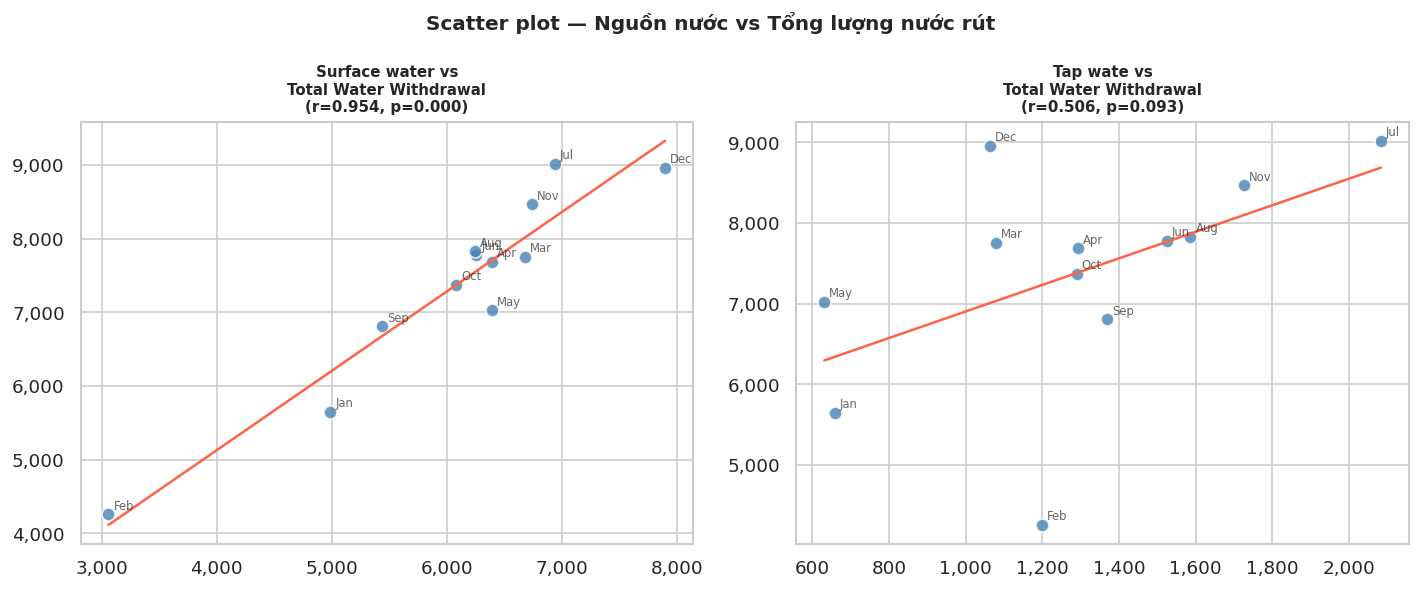

In [24]:
# Scatter: DV sources vs Total DV
pairs_plot = [
    ('Surface water (Lake) (DV)', 'Total Water Withdrawal (DV)'),
    ('Tap wate (DV)',              'Total Water Withdrawal (DV)'),
]
pairs_plot = [(a,b) for a,b in pairs_plot if a in pw.columns and b in pw.columns]

if pairs_plot:
    fig, axes = plt.subplots(1, len(pairs_plot), figsize=(12, 5))
    if len(pairs_plot) == 1:
        axes = [axes]
    for ax, (a, b) in zip(axes, pairs_plot):
        x, y = pw[a], pw[b]
        ax.scatter(x, y, s=60, color='steelblue', alpha=0.8, edgecolors='white')
        try:
            coeffs = np.polyfit(x.fillna(0), y.fillna(0), 1)
            xfit = np.linspace(x.min(), x.max(), 100)
            ax.plot(xfit, np.polyval(coeffs, xfit), color='tomato', linewidth=1.5)
        except: pass
        for xi, yi, m in zip(x, y, MONTHS):
            ax.annotate(m, (xi, yi), fontsize=7, alpha=0.7,
                        xytext=(3,3), textcoords='offset points')
        r, p = pearsonr(x.fillna(0), y.fillna(0))
        ax.set_title(f'{a.split("(")[0].strip()} vs\n{b.split("(")[0].strip()}\n(r={r:.3f}, p={p:.3f})',
                     fontsize=9, fontweight='bold')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    plt.suptitle('Scatter plot — Nguồn nước vs Tổng lượng nước rút', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

## 6. Tương quan DV vs YB


Missing — DV: 0 tháng | YB: 0 tháng
Tháng dùng được cho tương quan DV-YB: 12/12



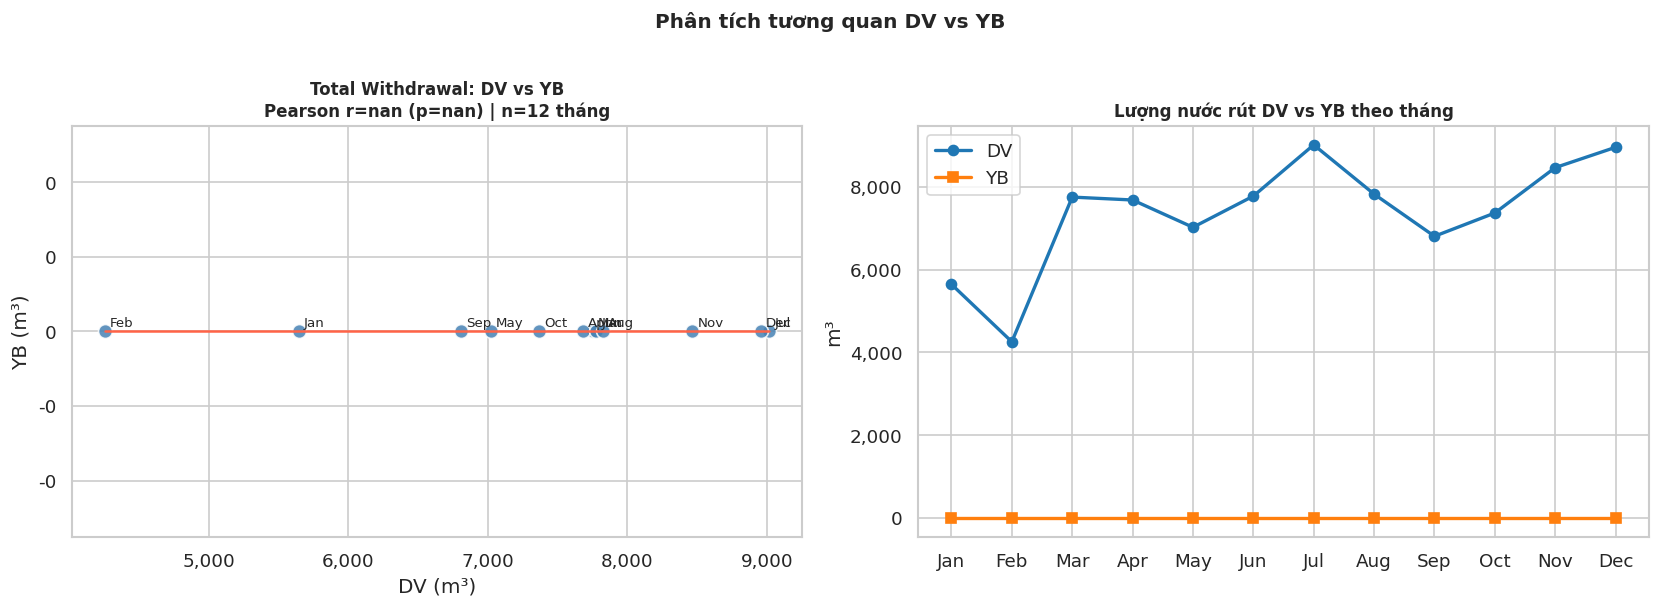

Pearson r = nan (n=12 tháng có đủ dữ liệu
Spearman r = nan
=> Hai nhà máy có xu hướng tương quan yếu/không rõ (exploratory, sample nhỏ)


In [25]:
from scipy.stats import pearsonr, spearmanr

dv_total = df_vol[df_vol['attribute'] == 'Total Water Withdrawal (DV)'].sort_values('period')['value'].values
yb_total = df_vol[df_vol['attribute'] == 'Total Water Withdrawal (YB)'].sort_values('period')['value'].values

dv_missing = np.isnan(dv_total).sum()
yb_missing = np.isnan(yb_total).sum()
print(f'Missing — DV: {dv_missing} tháng | YB: {yb_missing} tháng')

valid_mask = ~(np.isnan(dv_total) | np.isnan(yb_total))
n_valid = valid_mask.sum()
print(f'Tháng dùng được cho tương quan DV-YB: {n_valid}/12')
print()

if n_valid >= 3:
    r_p, p_p = pearsonr(dv_total[valid_mask], yb_total[valid_mask])
    r_s, p_s = spearmanr(dv_total[valid_mask], yb_total[valid_mask])
    has_corr = True
else:
    r_p = p_p = r_s = p_s = float('nan')
    has_corr = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(dv_total[valid_mask], yb_total[valid_mask], s=70, color='steelblue', edgecolors='white', alpha=0.85)
valid_months = [m for m, v in zip(MONTHS, valid_mask) if v]
for xi, yi, m in zip(dv_total[valid_mask], yb_total[valid_mask], valid_months):
    axes[0].annotate(m, (xi, yi), fontsize=8, xytext=(3,3), textcoords='offset points')
if has_corr:
    try:
        coeffs = np.polyfit(dv_total[valid_mask], yb_total[valid_mask], 1)
        xfit = np.linspace(np.nanmin(dv_total[valid_mask]), np.nanmax(dv_total[valid_mask]), 100)
        axes[0].plot(xfit, np.polyval(coeffs, xfit), color='tomato', linewidth=1.5)
    except: pass

title_str = (f'Total Withdrawal: DV vs YB\nPearson r={r_p:.3f} (p={p_p:.3f}) | n={n_valid} tháng'
             if has_corr else 'Total Withdrawal: DV vs YB\nKhông đủ dữ liệu (missing quá nhiều)')
axes[0].set_title(title_str, fontsize=10, fontweight='bold')
axes[0].set_xlabel('DV (m³)'); axes[0].set_ylabel('YB (m³)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

axes[1].plot(MONTHS, dv_total, marker='o', label='DV', linewidth=2)
axes[1].plot(MONTHS, yb_total, marker='s', label='YB', linewidth=2)
axes[1].set_title('Lượng nước rút DV vs YB theo tháng', fontsize=10, fontweight='bold')
axes[1].set_ylabel('m³'); axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.suptitle('Phân tích tương quan DV vs YB', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

if has_corr:
    print(f'Pearson r = {r_p:.3f} (n={n_valid} tháng có đủ dữ liệu')
    interp = 'tương quan dương mạnh' if r_p > 0.6 else ('tương quan âm' if r_p < -0.3 else 'tương quan yếu/không rõ')
    print(f'Spearman r = {r_s:.3f}')
    print(f'=> Hai nhà máy có xu hướng {interp} (exploratory, sample nhỏ)')
else:
    print('Pearson ra NaN: Không đủ tháng có đủ cả DV và YB để tính tương quan.')
    print('   Nguyên nhân: YB có nhiều missing value.')
    print('   => Không thể kết luận về quan hệ DV-YB cho đến khi dữ liệu được bổ sung/giải thích.')


## 7. ANOVA — Theo quý & theo địa điểm


In [26]:
quarter_map = {'Jan':'Q1','Feb':'Q1','Mar':'Q1',
               'Apr':'Q2','May':'Q2','Jun':'Q2',
               'Jul':'Q3','Aug':'Q3','Sep':'Q3',
               'Oct':'Q4','Nov':'Q4','Dec':'Q4'}

df_total_anova = df_vol[
    df_vol['attribute'] == 'Total Water Withdrawal (DV+YB)'
].dropna(subset=['value']).copy()
df_total_anova['quarter'] = df_total_anova['period'].astype(str).map(quarter_map)

q_groups = [df_total_anova[df_total_anova['quarter'] == q]['value'].values
            for q in ['Q1','Q2','Q3','Q4']]
q_groups = [g for g in q_groups if len(g) > 0]

print('=' * 60)
print('ONE-WAY ANOVA — Total Water Withdrawal theo Quý')
print('=' * 60)
if len(q_groups) >= 2:
    F, p = f_oneway(*q_groups)
    print(f'  F-statistic : {F:.4f}')
    print(f'  p-value     : {p:.4f}')
    print(f'  Kết luận    : {"Có sự khác biệt theo quý (mùa vụ)" if p < 0.05 else "Không khác biệt đáng kể theo quý"}')
    print()
    H, p_kw = kruskal(*q_groups)
    print('KRUSKAL-WALLIS (phi tham số):')
    print(f'  H = {H:.4f}, p = {p_kw:.4f}')
    print(f'  Kết luận: {"Phân phối khác nhau theo quý" if p_kw < 0.05 else "Không khác biệt"}')
else:
    print('Không đủ nhóm để thực hiện ANOVA.')

ONE-WAY ANOVA — Total Water Withdrawal theo Quý
  F-statistic : 2.5489
  p-value     : 0.1290
  Kết luận    : Không khác biệt đáng kể theo quý

KRUSKAL-WALLIS (phi tham số):
  H = 3.9744, p = 0.2642
  Kết luận: Không khác biệt


In [27]:
# ANOVA: DV vs YB (so sánh mức tiêu thụ hai địa điểm)
dv_vals = df_vol[df_vol['attribute'] == 'Total Water Withdrawal (DV)']['value'].dropna().values
yb_vals = df_vol[df_vol['attribute'] == 'Total Water Withdrawal (YB)']['value'].dropna().values

print('=' * 60)
print('ANOVA / T-Test — Total Withdrawal DV vs YB')
print('=' * 60)
if len(dv_vals) > 1 and len(yb_vals) > 1:
    F2, p2 = f_oneway(dv_vals, yb_vals)
    t, pt = ttest_ind(dv_vals, yb_vals, equal_var=False)
    print(f'  ANOVA F = {F2:.4f}, p = {p2:.4f}')
    print(f'  Welch t = {t:.4f}, p = {pt:.4f}')
    print(f'  Mean DV = {dv_vals.mean():,.2f} m³ | Mean YB = {yb_vals.mean():,.2f} m³')
    print(f'  Kết luận: DV và YB {"có" if pt < 0.05 else "không có"} khác biệt đáng kể về lượng nước rút')

ANOVA / T-Test — Total Withdrawal DV vs YB
  ANOVA F = 356.7123, p = 0.0000
  Welch t = 18.8868, p = 0.0000
  Mean DV = 7,382.25 m³ | Mean YB = 0.00 m³
  Kết luận: DV và YB có khác biệt đáng kể về lượng nước rút


## 8. T-Test — So sánh từng cặp chỉ số


In [28]:
attrs_m3 = [a for a in df_vol['attribute'].unique()]
ttest_res = []
for a1, a2 in combinations(attrs_m3, 2):
    g1 = df_vol[df_vol['attribute'] == a1]['value'].dropna()
    g2 = df_vol[df_vol['attribute'] == a2]['value'].dropna()
    if len(g1) < 2 or len(g2) < 2:
        continue
    t, p = ttest_ind(g1, g2, equal_var=False)
    ttest_res.append({'Chỉ số A': a1, 'Chỉ số B': a2,
                       't-stat': round(t,3), 'p-value': round(p,4),
                       'p<0.05': 'Yes' if p < 0.05 else 'No'})

df_tt = pd.DataFrame(ttest_res).sort_values('p-value')
n_tests = len(df_tt)
alpha_bonf = 0.05 / n_tests if n_tests > 0 else 0.05
df_tt['Bonferroni'] = df_tt['p-value'].apply(lambda p: 'Yes' if p < alpha_bonf else 'No')

print(f'Welch t-test — {n_tests} cặp chỉ số (n=12 tháng/chỉ số):')
print(f"  Có khác biệt (p<0.05, chưa điều chỉnh): {(df_tt['p-value'] < 0.05).sum()} cặp")
print(f'  Bonferroni alpha = 0.05/{n_tests} = {alpha_bonf:.5f}')
print(f"  Có khác biệt (Bonferroni): {(df_tt['p-value'] < alpha_bonf).sum()} cặp")
print()
print('Cảnh báo: Cỡ mẫu nhỏ (n=12) và dữ liệu time-series => kết quả mang tính exploratory.')
print('   Nhiều cặp "có khác biệt" khi chưa điều chỉnh có thể là false positive.')
print()
print('Top 10 cặp khác biệt rõ nhất:')
display(df_tt.head(10))


Welch t-test — 28 cặp chỉ số (n=12 tháng/chỉ số):
  Có khác biệt (p<0.05, chưa điều chỉnh): 23 cặp
  Bonferroni alpha = 0.05/28 = 0.00179
  Có khác biệt (Bonferroni): 19 cặp

Cảnh báo: Cỡ mẫu nhỏ (n=12) và dữ liệu time-series => kết quả mang tính exploratory.
   Nhiều cặp "có khác biệt" khi chưa điều chỉnh có thể là false positive.

Top 10 cặp khác biệt rõ nhất:


,Chỉ số A,Chỉ số B,t-stat,p-value,p<0.05,Bonferroni
0,Surface water (Lake) (DV),Surface water (Lake) (YB),17.604,0.0,Yes,Yes
2,Surface water (Lake) (DV),Ground water (wells) (DV),17.604,0.0,Yes,Yes
3,Surface water (Lake) (DV),Tap wate (DV),13.104,0.0,Yes,Yes
5,Surface water (Lake) (DV),Total Water Withdrawal (YB),17.604,0.0,Yes,Yes
7,Surface water (Lake) (YB),Surface water (Lake) (DV+YB),-17.604,0.0,Yes,Yes
12,Surface water (Lake) (YB),Total Water Withdrawal (DV+YB),-18.887,0.0,Yes,Yes
10,Surface water (Lake) (YB),Total Water Withdrawal (DV),-18.887,0.0,Yes,Yes
9,Surface water (Lake) (YB),Tap wate (DV),-10.750,0.0,Yes,Yes
14,Surface water (Lake) (DV+YB),Tap wate (DV),13.104,0.0,Yes,Yes
16,Surface water (Lake) (DV+YB),Total Water Withdrawal (YB),17.604,0.0,Yes,Yes


## 9. Trend detection — Tương quan với thời gian


Tương quan Spearman với thứ tự tháng (trend detector):


,Chỉ số,Spearman r,p-value,Xu hướng
6,Total Water Withdrawal (DV+YB),0.594,0.0415,Tăng
5,Total Water Withdrawal (DV),0.594,0.0415,Tăng
1,Surface water (Lake) (DV),0.462,0.1309,Ổn định
2,Surface water (Lake) (DV+YB),0.462,0.1309,Ổn định
4,Tap wate (DV),0.399,0.1993,Ổn định
0,Ground water (wells) (DV),NaN,NaN,Ổn định
3,Surface water (Lake) (YB),NaN,NaN,Ổn định
7,Total Water Withdrawal (YB),NaN,NaN,Ổn định


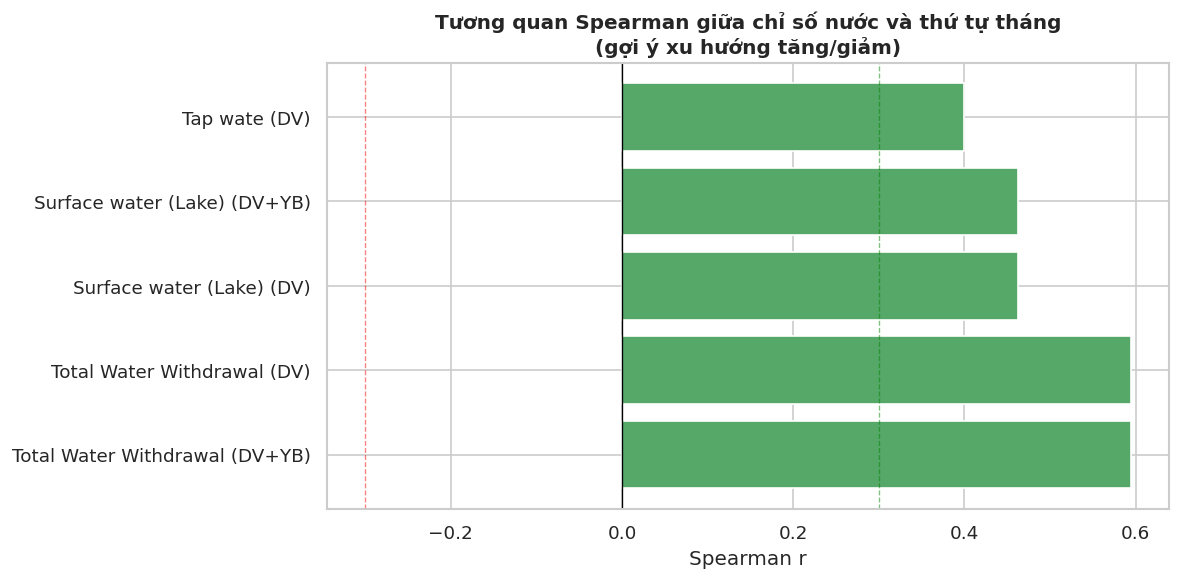

In [29]:
month_nums = np.arange(1, 13)
trend_res = []

for attr in pw.columns:
    vals = pw[attr].values
    r, p = spearmanr(month_nums, vals)
    trend = 'Tăng' if r > 0.3 and p < 0.1 else ('Giảm' if r < -0.3 and p < 0.1 else 'Ổn định')
    trend_res.append({'Chỉ số': attr, 'Spearman r': round(r,3),
                       'p-value': round(p,4), 'Xu hướng': trend})

df_tr = pd.DataFrame(trend_res).sort_values('Spearman r', ascending=False)
print('Tương quan Spearman với thứ tự tháng (trend detector):')
display(df_tr)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#C44E52' if r < 0 else '#55A868' for r in df_tr['Spearman r']]
ax.barh(df_tr['Chỉ số'], df_tr['Spearman r'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.axvline(0.3, color='green', lw=0.8, ls='--', alpha=0.5)
ax.axvline(-0.3, color='red', lw=0.8, ls='--', alpha=0.5)
ax.set_title('Tương quan Spearman giữa chỉ số nước và thứ tự tháng\n(gợi ý xu hướng tăng/giảm)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Spearman r')
plt.tight_layout(); plt.show()

## 9b. Rolling Trend & Month-over-Month Growth


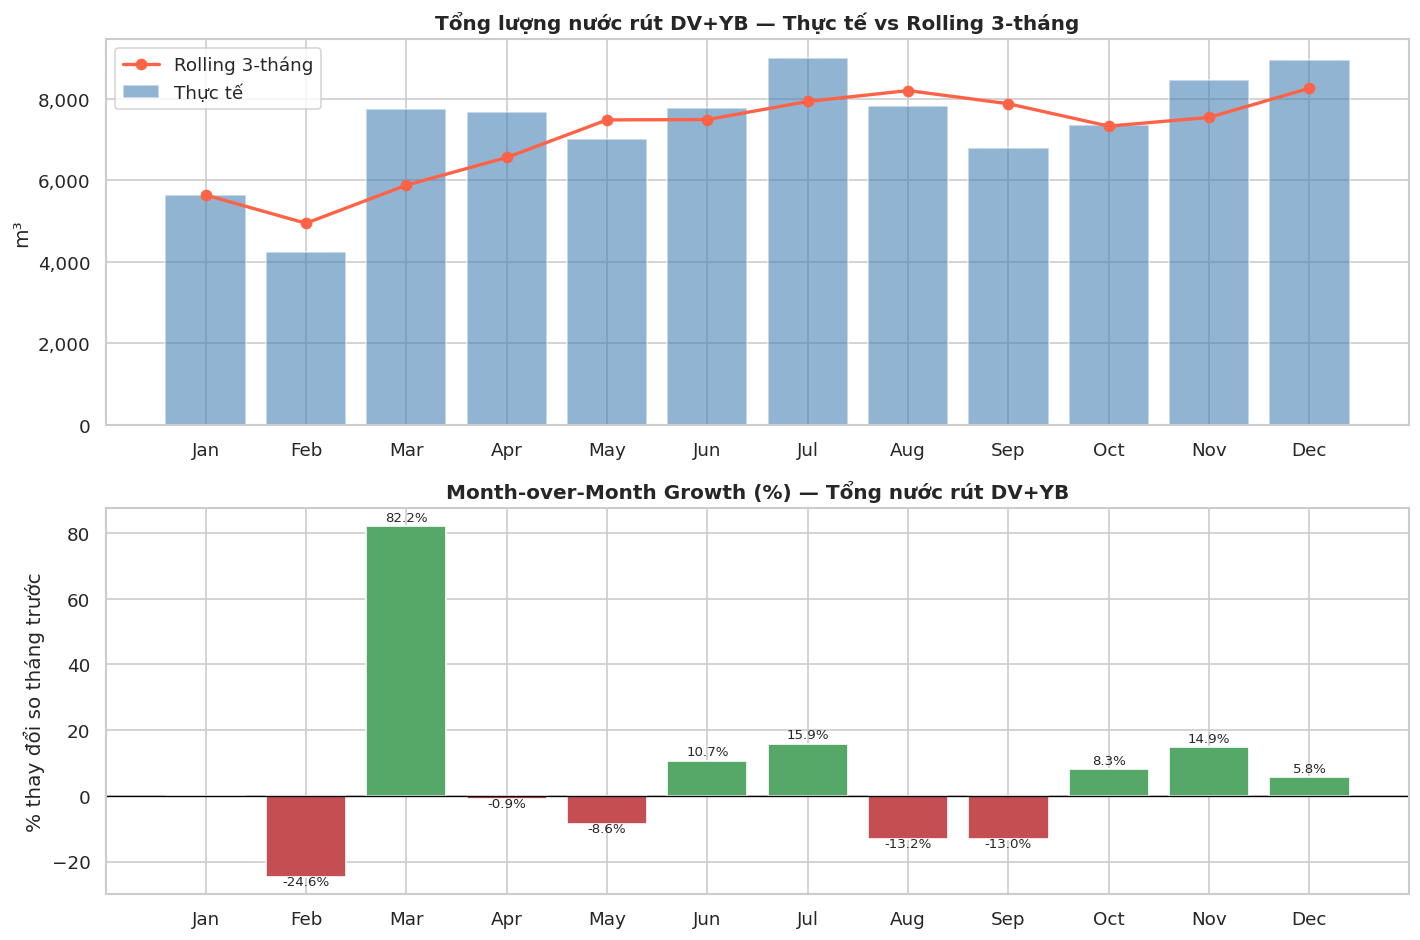

In [30]:
# Rolling trend & Month-over-Month Growth
total_series = df_vol[df_vol['attribute'] == 'Total Water Withdrawal (DV+YB)'].sort_values('period').set_index('period')['value']

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Rolling 3-month mean
rolling3 = total_series.rolling(3, min_periods=1).mean()
axes[0].bar(total_series.index.astype(str), total_series.values, color='steelblue', alpha=0.6, label='Thực tế')
axes[0].plot(total_series.index.astype(str), rolling3.values, color='tomato', linewidth=2, marker='o', label='Rolling 3-tháng')
axes[0].set_title('Tổng lượng nước rút DV+YB — Thực tế vs Rolling 3-tháng', fontsize=12, fontweight='bold')
axes[0].set_ylabel('m³')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].legend()

# Month-over-Month growth
mom = total_series.pct_change() * 100
colors_mom = ['#55A868' if v >= 0 else '#C44E52' for v in mom.fillna(0)]
axes[1].bar(total_series.index.astype(str), mom.fillna(0), color=colors_mom, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Month-over-Month Growth (%) — Tổng nước rút DV+YB', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% thay đổi so tháng trước')
for i, (m, v) in enumerate(zip(total_series.index.astype(str), mom.fillna(0))):
    if i > 0:
        axes[1].text(i, v + (1.5 if v >= 0 else -2.5), f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout(); plt.show()


## 9c. Cơ cấu nguồn nước (DV)


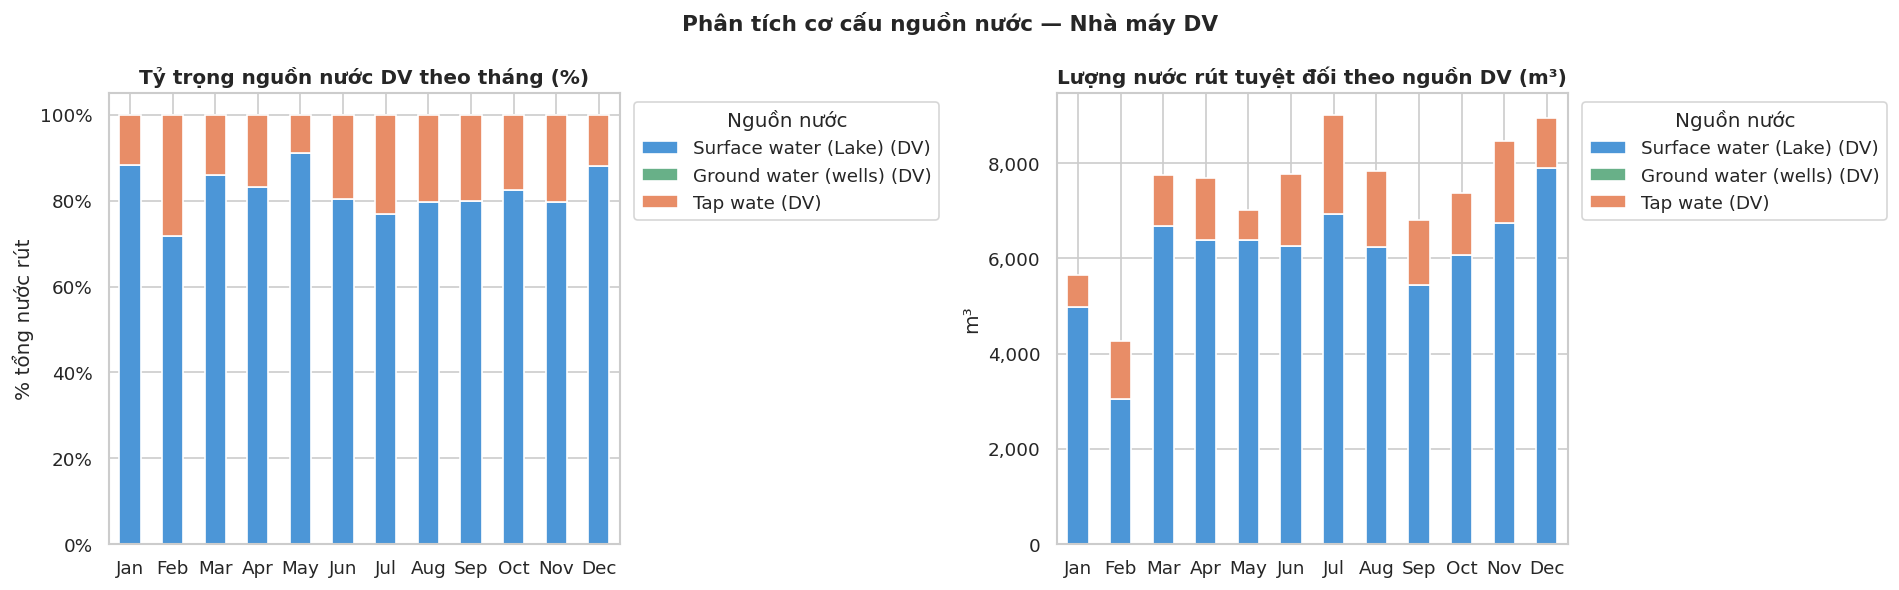

Tỷ trọng trung bình cả năm theo nguồn:


attribute,Surface water (Lake) (DV),Ground water (wells) (DV),Tap wate (DV)
% trung bình,82.3,0.0,17.7


In [31]:
source_cols = ['Surface water (Lake) (DV)', 'Ground water (wells) (DV)', 'Tap wate (DV)']
pivot_vol = df_vol.pivot_table(index='period', columns='attribute', values='value').reindex(MONTHS)
available_sources = [c for c in source_cols if c in pivot_vol.columns]

if available_sources:
    prop_df = pivot_vol[available_sources].copy()
    row_total = prop_df.sum(axis=1).replace(0, np.nan)
    prop_pct = prop_df.div(row_total, axis=0) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    prop_pct.plot(kind='bar', stacked=True, ax=axes[0],
                  color=['#4C96D7', '#68B088', '#E88D67'], edgecolor='white')
    axes[0].set_title('Tỷ trọng nguồn nước DV theo tháng (%)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('% tổng nước rút')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].legend(title='Nguồn nước', bbox_to_anchor=(1.01, 1))
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))

    prop_df.plot(kind='bar', stacked=True, ax=axes[1],
                 color=['#4C96D7', '#68B088', '#E88D67'], edgecolor='white')
    axes[1].set_title('Lượng nước rút tuyệt đối theo nguồn DV (m³)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('m³')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(title='Nguồn nước', bbox_to_anchor=(1.01, 1))
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

    plt.suptitle('Phân tích cơ cấu nguồn nước — Nhà máy DV', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    print('Tỷ trọng trung bình cả năm theo nguồn:')
    display(prop_pct.mean().round(1).to_frame('% trung bình').T)
else:
    print('Không đủ dữ liệu nguồn nước DV để tính tỷ trọng.')


## 10. Tương quan Total Withdrawal vs Specific Withdrawal


Pearson r = -0.356, p = 0.257
Giải thích: r gần 0 → lượng nước tuyệt đối và hiệu quả dùng nước không tuyến tính


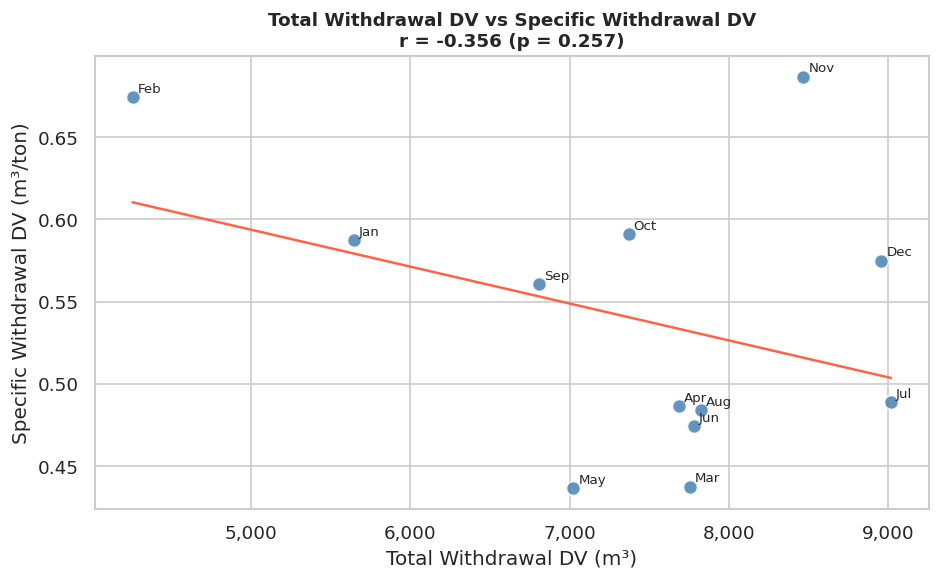

In [32]:
sp_dv = df_spec[df_spec['attribute'] == 'Specific Water Withdrawal (DV)'].sort_values('period')['value'].values
tot_dv = df_vol[df_vol['attribute'] == 'Total Water Withdrawal (DV)'].sort_values('period')['value'].values

valid = ~(np.isnan(sp_dv) | np.isnan(tot_dv))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(tot_dv[valid], sp_dv[valid], s=70, color='steelblue', edgecolors='white', alpha=0.85)
for xi, yi, m in zip(tot_dv[valid], sp_dv[valid], np.array(MONTHS)[valid]):
    ax.annotate(m, (xi, yi), fontsize=8, xytext=(3,3), textcoords='offset points')

if valid.sum() > 2:
    r, p = pearsonr(tot_dv[valid], sp_dv[valid])
    coeffs = np.polyfit(tot_dv[valid], sp_dv[valid], 1)
    xfit = np.linspace(tot_dv[valid].min(), tot_dv[valid].max(), 100)
    ax.plot(xfit, np.polyval(coeffs, xfit), color='tomato', linewidth=1.5)
    ax.set_title(f'Total Withdrawal DV vs Specific Withdrawal DV\nr = {r:.3f} (p = {p:.3f})',
                 fontsize=11, fontweight='bold')
    print(f'Pearson r = {r:.3f}, p = {p:.3f}')
    print('Giải thích: r gần 0 → lượng nước tuyệt đối và hiệu quả dùng nước không tuyến tính')

ax.set_xlabel('Total Withdrawal DV (m³)')
ax.set_ylabel('Specific Withdrawal DV (m³/ton)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout(); plt.show()

## 11. Outliers — IQR & Z-Score


In [33]:
iqr_out, z_out = [], []

for attr in df_vol['attribute'].unique():
    sub = df_vol[df_vol['attribute'] == attr][['period','value']].dropna()
    if len(sub) < 4: continue
    Q1, Q3 = sub['value'].quantile(0.25), sub['value'].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    for _, r in sub[(sub['value'] < lo) | (sub['value'] > hi)].iterrows():
        iqr_out.append({'Method':'IQR','Chỉ số':attr,'Tháng':str(r['period']),
                         'value':r['value'],'lower':round(lo,2),'upper':round(hi,2),
                         'Khuyến nghị': 'Điều tra thêm — có thể do seasonality hoặc vận hành đặc biệt'})
    if sub['value'].std() > 0:
        z = np.abs(stats.zscore(sub['value']))
        for (_, row), zi in zip(sub.iterrows(), z):
            if zi > 2.5:
                z_out.append({'Method':'Z-Score','Chỉ số':attr,'Tháng':str(row['period']),
                               'value':row['value'],'z-score':round(zi,3),
                               'Khuyến nghị': 'Điều tra thêm — có thể do seasonality hoặc vận hành đặc biệt'})

print(f'IQR method    => {len(iqr_out)} outlier(s)')
print(f'Z-Score (>2.5) => {len(z_out)} outlier(s)')
if iqr_out: display(pd.DataFrame(iqr_out))
if z_out:   display(pd.DataFrame(z_out))
if not iqr_out and not z_out: print('Không phát hiện outlier đáng kể.')


IQR method    => 6 outlier(s)
Z-Score (>2.5) => 2 outlier(s)


,Method,Chỉ số,Tháng,value,lower,upper,Khuyến nghị
0,IQR,Surface water (Lake) (DV),Feb,3058.0,4763.38,7848.38,Điều tra thêm — có thể do seasonality hoặc vận...
1,IQR,Surface water (Lake) (DV),Dec,7894.0,4763.38,7848.38,Điều tra thêm — có thể do seasonality hoặc vận...
2,IQR,Surface water (Lake) (DV+YB),Feb,3058.0,4763.38,7848.38,Điều tra thêm — có thể do seasonality hoặc vận...
3,IQR,Surface water (Lake) (DV+YB),Dec,7894.0,4763.38,7848.38,Điều tra thêm — có thể do seasonality hoặc vận...
4,IQR,Total Water Withdrawal (DV),Feb,4256.0,5443.88,9512.88,Điều tra thêm — có thể do seasonality hoặc vận...
5,IQR,Total Water Withdrawal (DV+YB),Feb,4256.0,5443.88,9512.88,Điều tra thêm — có thể do seasonality hoặc vận...


,Method,Chỉ số,Tháng,value,z-score,Khuyến nghị
0,Z-Score,Surface water (Lake) (DV),Feb,3058.0,2.643,Điều tra thêm — có thể do seasonality hoặc vận...
1,Z-Score,Surface water (Lake) (DV+YB),Feb,3058.0,2.643,Điều tra thêm — có thể do seasonality hoặc vận...


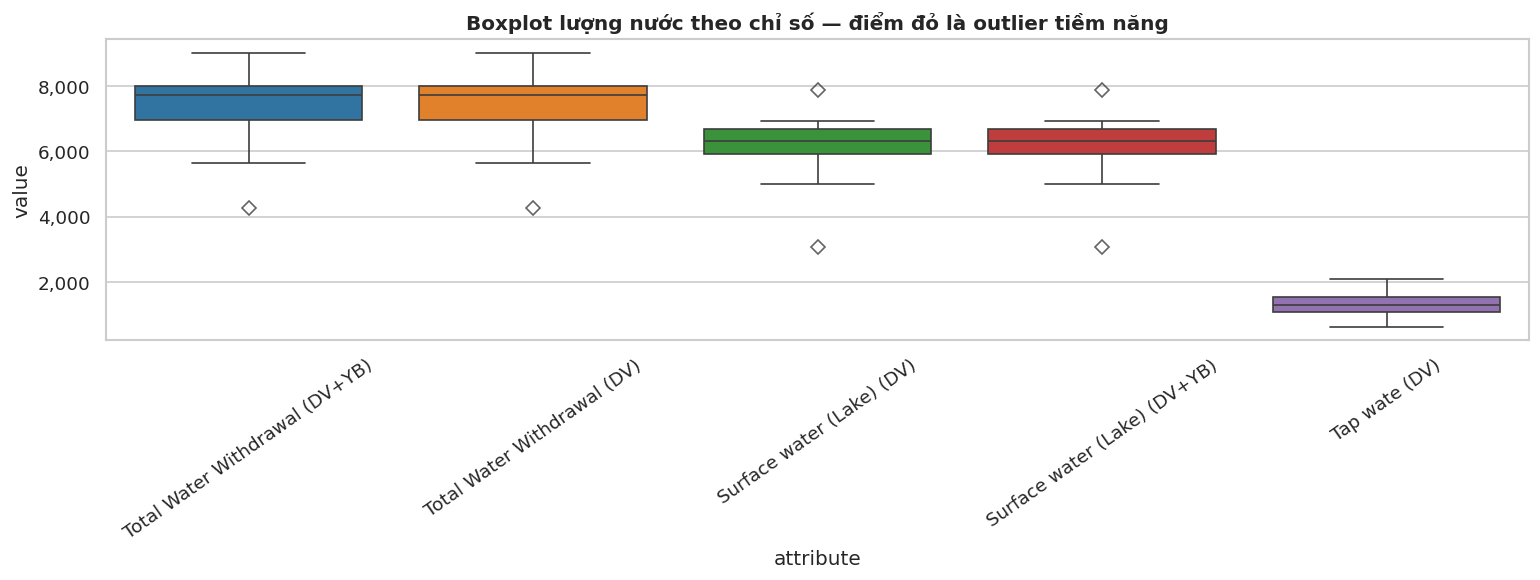

In [34]:
# Boxplot với highlight outlier
df_nz = df_vol[df_vol['value'] > 0].dropna()
order_b = df_nz.groupby('attribute')['value'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df_nz, x='attribute', y='value', order=order_b,
            palette='tab10', ax=ax,
            flierprops=dict(marker='D', color='red', markersize=6, alpha=0.8))
ax.set_title('Boxplot lượng nước theo chỉ số — điểm đỏ là outlier tiềm năng',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=35)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout(); plt.show()

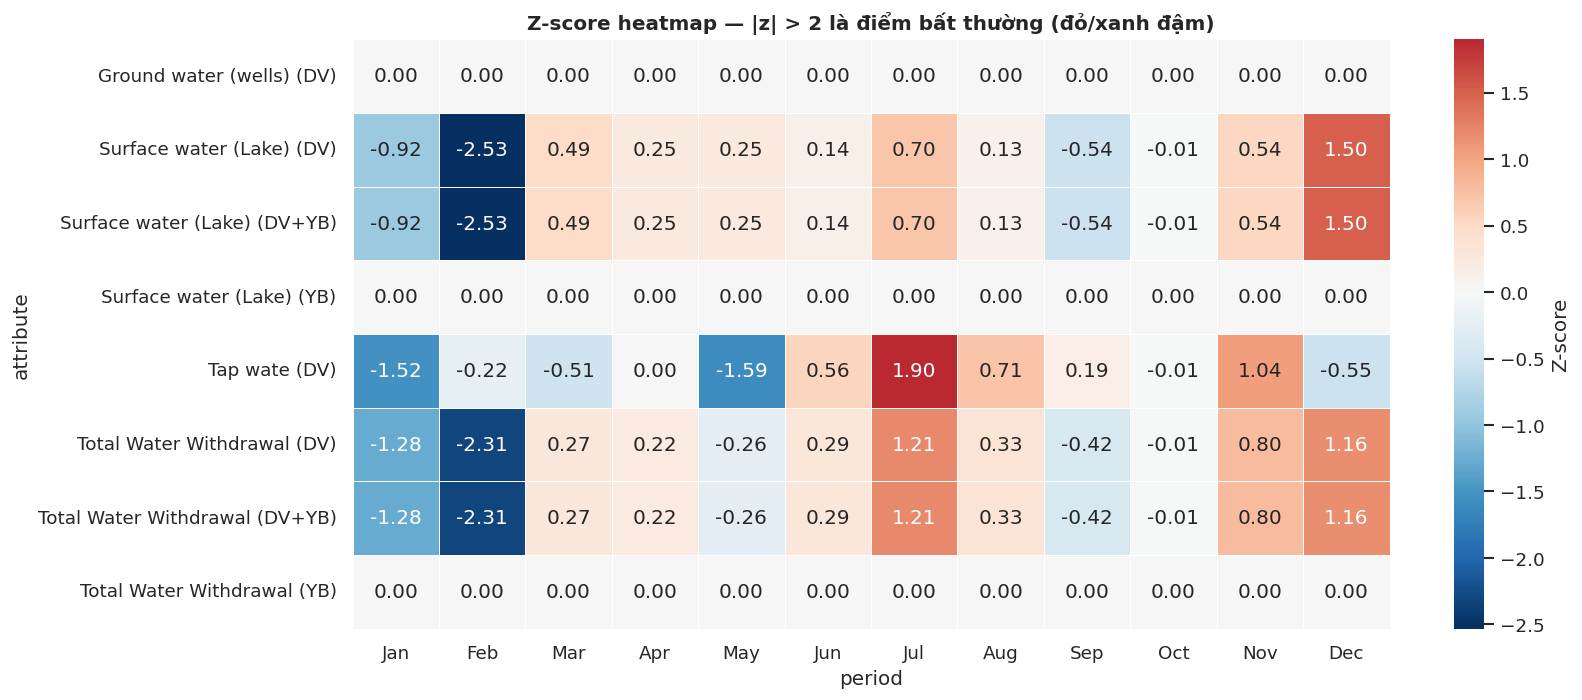

In [35]:
# Z-score heatmap — mức độ bất thường từng tháng
zscore_pivot = pw.apply(
    lambda col: (col - col.mean()) / col.std() if col.std() > 0 else col * 0
).T  # rows=attributes, cols=months for heatmap

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(zscore_pivot, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, ax=ax, cbar_kws={'label': 'Z-score'})
ax.set_title('Z-score heatmap — |z| > 2 là điểm bất thường (đỏ/xanh đậm)',
             fontsize=12, fontweight='bold')
plt.yticks(rotation=0); plt.tight_layout(); plt.show()

## 12. Clustering tháng & chỉ số


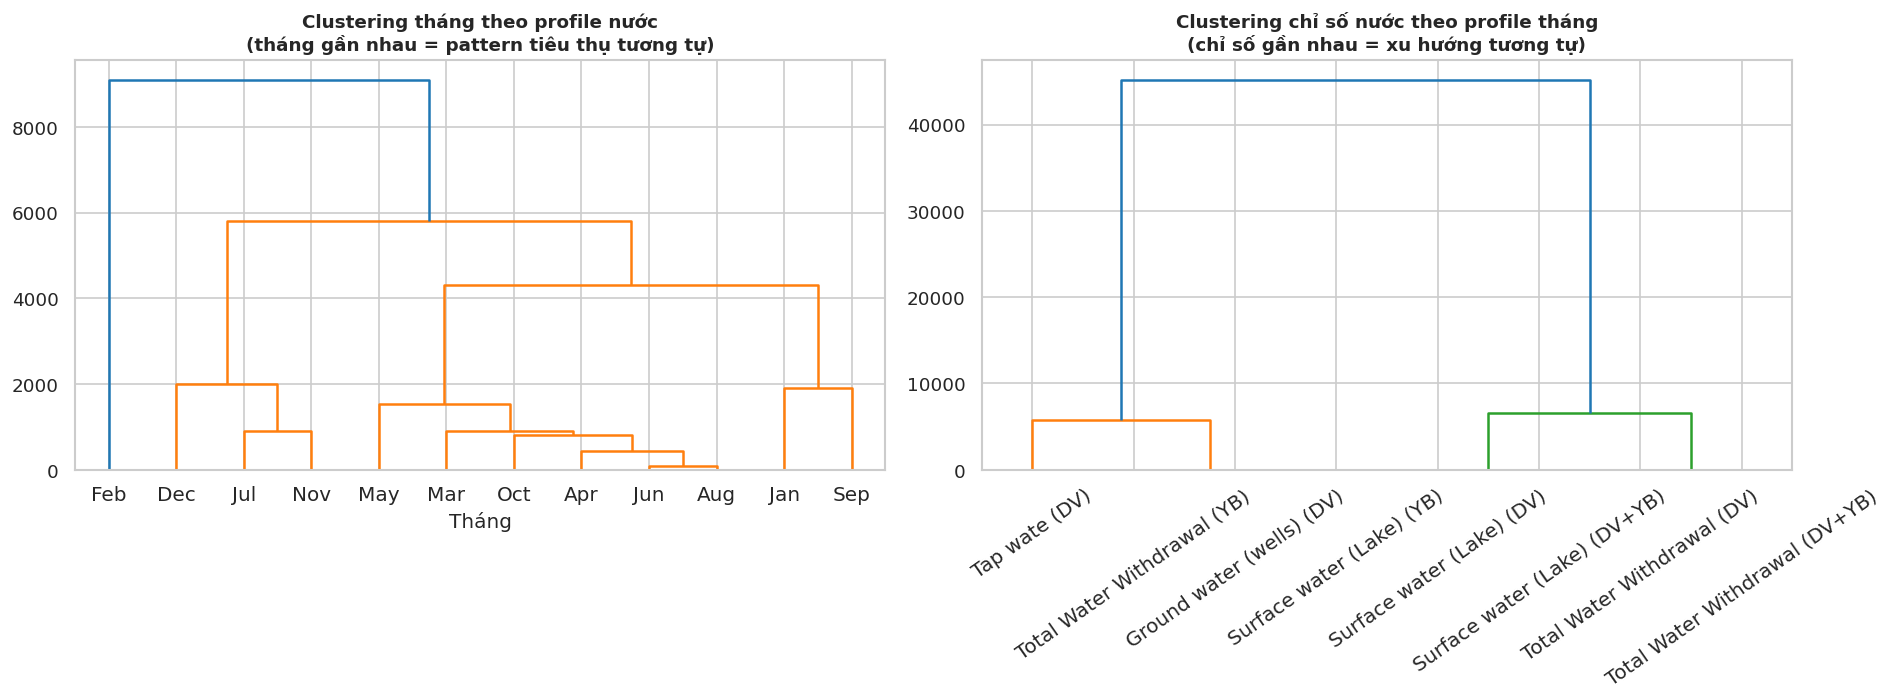

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clustering tháng
Z_m = linkage(pw.fillna(0).values, method='ward')
dendrogram(Z_m, labels=list(pw.index.astype(str)), ax=axes[0],
           color_threshold=0.7*max(Z_m[:,2]))
axes[0].set_title('Clustering tháng theo profile nước\n(tháng gần nhau = pattern tiêu thụ tương tự)',
                   fontsize=11, fontweight='bold')
axes[0].set_xlabel('Tháng')

# Clustering chỉ số
Z_a = linkage(pw.T.fillna(0).values, method='ward')
dendrogram(Z_a, labels=list(pw.columns), ax=axes[1],
           color_threshold=0.7*max(Z_a[:,2]), leaf_rotation=35)
axes[1].set_title('Clustering chỉ số nước theo profile tháng\n(chỉ số gần nhau = xu hướng tương tự)',
                   fontsize=11, fontweight='bold')

plt.tight_layout(); plt.show()